In [68]:
from src.helpers.model_matrix import build_model_matrix_from_wrds

In [69]:
from src.helpers.model_matrix import align_and_fill_dates_across_tickers

In [ ]:

import warnings

import numpy as np
import pandas as pd
import pandas_ta as ta
import yfinance as yf


def _flatten_price_columns(df: pd.DataFrame) -> pd.DataFrame:
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy()
        df.columns = df.columns.get_level_values(0)
    return df


def _as_series(obj: pd.Series | pd.DataFrame, name: str) -> pd.Series:
    if isinstance(obj, pd.DataFrame):
        if name in obj.columns:
            return obj[name]
        return obj.iloc[:, 0]
    return obj.rename(name) if obj.name != name else obj


def prepare_daily_indicator_dataset(
    ticker: str,
    start: str | None = '2000-01-01',
    end: str | None = None,
    horizon: int = 1,
    dropna: bool = True,
    min_obs: int = 60,
) -> pd.DataFrame:
    daily = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)
    if daily.empty:
        raise ValueError('No price history returned by yfinance.')
    daily = _flatten_price_columns(daily)
    daily = daily[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].dropna()
    daily.index = daily.index.tz_localize(None)
    daily = daily.sort_index()
    if len(daily) < max(min_obs, 35):
        raise ValueError('Not enough observations to compute indicators.')

    high = daily['High']
    low = daily['Low']
    close = daily['Close']
    adj_close = daily['Adj Close']
    volume = daily['Volume'].astype(float)

    log_rets = np.log(adj_close).diff()

    frame = pd.DataFrame(index=daily.index)
    frame['date'] = daily.index
    frame['adjclose_lead'] = log_rets.shift(-horizon)
    frame['direction_lead'] = np.where(frame['adjclose_lead'] > 0, 1, 0)
    frame.loc[frame['adjclose_lead'].isna(), 'direction_lead'] = np.nan
    frame['adjclose_lag0'] = log_rets
    frame['adjclose_lag1'] = log_rets.shift(1)
    frame['adjclose_lag2'] = log_rets.shift(2)
    frame['adjclose_lag3'] = log_rets.shift(3)

    # pandas_ta indicators
    frame['atr_14'] = ta.atr(high=high, low=low, close=close, length=14)

    adx = ta.adx(high=high, low=low, close=close, length=14)
    if adx is not None and 'ADX_14' in adx:
        frame['adx_14'] = adx['ADX_14']

    bb = ta.bbands(close=close, length=20, std=2)
    if isinstance(bb, pd.DataFrame):
        percent_col = next((col for col in bb.columns if col.startswith('BBP_')), None)
        if percent_col is not None:
            frame['bb_percent_20_2'] = bb[percent_col]

    macd = ta.macd(close=close, fast=12, slow=26, signal=9)
    if macd is not None and 'MACD_12_26_9' in macd:
        frame['macd_12_26_9'] = macd['MACD_12_26_9']

    mfi = ta.mfi(high=high, low=low, close=close, volume=volume, length=14)
    frame['mfi_14'] = _as_series(mfi, 'mfi_14')

    psar = ta.psar(high=high, low=low, close=close, step=0.02, max=0.2)
    if psar is not None and 'PSARaf_0.02_0.2' in psar:
        frame['psar_acc'] = psar['PSARaf_0.02_0.2']

    cmf = ta.cmf(high=high, low=low, close=close, volume=volume, length=20)
    frame['cmf_20'] = _as_series(cmf, 'cmf_20')

    eom = ta.eom(high=high, low=low, close=close, volume=volume, length=14)
    if eom is not None:
        frame['eom_14'] = _as_series(eom, 'eom_14')

    frame['rsi_14'] = _as_series(ta.rsi(close=close, length=14), 'rsi_14')
    frame['variance_21'] = _as_series(ta.variance(close=close, length=21), 'variance_21')

    stoch = ta.stoch(high=high, low=low, close=close, k=14, d=3, smooth_k=3)
    if stoch is not None and 'STOCHk_14_3_3' in stoch:
        frame['stoch_k_14_3_3'] = stoch['STOCHk_14_3_3']

    frame['skew_63'] = _as_series(ta.skew(close=close, length=63), 'skew_63')
    frame['kurtosis_63'] = _as_series(ta.kurtosis(close=close, length=63), 'kurtosis_63')

    aroon = ta.aroon(high=high, low=low, length=25)
    if aroon is not None and 'AROONOSC_25' in aroon:
        frame['aroon_osc_25'] = aroon['AROONOSC_25']

    frame = frame.dropna(axis=1, how='all')

    essential_cols = [
        'adjclose_lead',
        'direction_lead',
        'adjclose_lag0',
        'adjclose_lag1',
        'adjclose_lag2',
        'adjclose_lag3',
    ]
    essential_cols = [col for col in essential_cols if col in frame.columns]

    warmup = 63
    if len(frame) > warmup:
        frame = frame.iloc[warmup:].copy()

    if essential_cols:
        frame = frame.dropna(subset=essential_cols)

    indicator_cols = [col for col in frame.columns if col not in {'date'}]

    if indicator_cols:
        frame[indicator_cols] = (
            frame[indicator_cols]
            .ffill()
            .bfill()
            .fillna(0)
        )

    if dropna:
        frame = frame.dropna().reset_index(drop=True)
    else:
        frame = frame.reset_index(drop=True)

    if len(frame) < min_obs:
        raise ValueError('Not enough post-processing observations.')
    return frame


def prepare_daily_indicator_panel(
    tickers: list[str],
    start: str | None = '2000-01-01',
    end: str | None = None,
    horizon: int = 1,
    dropna: bool = True,
    min_obs: int = 60,
    warmup_buffer_days: int = 120,
) -> pd.DataFrame:
    frames = []
    requested_start = pd.to_datetime(start) if start is not None else None
    buffered_start = None
    if requested_start is not None:
        buffered_start = (requested_start - pd.Timedelta(days=warmup_buffer_days)).strftime('%Y-%m-%d')

    for ticker in tickers:
        data_start = buffered_start if buffered_start is not None else start
        try:
            frame = prepare_daily_indicator_dataset(
                ticker=ticker,
                start=data_start,
                end=end,
                horizon=horizon,
                dropna=dropna,
                min_obs=min_obs,
            )
        except ValueError as exc:
            warnings.warn(f'Skipping {ticker}: {exc}')
            continue
        frame['ticker'] = ticker
        frames.append(frame)
    if not frames:
        raise ValueError('No data downloaded for the provided tickers.')
    panel = (
        pd.concat(frames, ignore_index=True)
        .assign(date=lambda df_: pd.to_datetime(df_['date']))
        .sort_values(['ticker', 'date'])
        .set_index(['ticker', 'date'])
    )
    if requested_start is not None:
        panel = panel[panel.index.get_level_values('date') >= requested_start]
    return panel


all_tickers = [
    "NVDA", "AAPL", "MSFT", "GOOGL", "AMZN", "META", "AVGO", "TSLA", "BRK-B", "JPM",
    "ORCL", "WMT", "V", "LLY", "NFLX", "MA", "XOM", "JNJ", "COST", "HD",
    "ABBV", "BAC", "PG", "CVX", "MRK", "KO", "PEP", "AMD", "CRM", "TSM",
    "MCD", "ACN", "CSCO", "TMO", "LIN", "WFC", "ADBE", "TXN", "BABA", "NKE",
    "QCOM", "DHR", "AMGN", "PFE", "MS", "UNH", "UPS", "CAT", "HON", "AMAT",
    "GS", "SCHW", "RTX", "BKNG", "LMT", "PM", "AMT", "IBM", "INTC", "BLK",
    "GE", "DE", "ADP", "SBUX", "SPGI", "GILD", "COP", "CME", "ISRG", "USB",
    "CVS", "NOW", "PYPL", "ELV", "C", "BX", "EQIX", "ABNB", "CI", "MU",
    "MDT", "UNP", "ZTS", "MO", "T", "INTU", "HCA", "SYK", "MMC", "CB",
    "PLD", "CHTR", "ICE", "PANW", "TGT", "REGN", "GM", "ADI", "CSX", "FISV",
    "VRTX", "FIS", "PGR", "NSC", "EOG", "CL", "SO", "AON", "DUK", "KDP"
]
# Build a multi-ticker daily panel ready for modelling.
daily_indicator_panel = prepare_daily_indicator_panel(
    tickers=all_tickers,
    start='2015-01-01',
    end='2019-12-31',
    horizon=1,
    dropna=True,
    min_obs=120,
)

daily_indicator_panel



1 Failed download:
['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')
C:\Users\justi\AppData\Local\Temp\ipykernel_12788\3510712541.py:171: UserWarning: Skipping BRK.B: No price history returned by yfinance.
  warnings.warn(f'Skipping {ticker}: {exc}')

1 Failed download:
['ABNB']: YFPricesMissingError('possibly delisted; no price data found  (1d 2014-09-03 -> 2019-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 1409716800, endDate = 1577768400")')
C:\Users\justi\AppData\Local\Temp\ipykernel_12788\3510712541.py:171: UserWarning: Skipping ABNB: No price history returned by yfinance.
  warnings.warn(f'Skipping {ticker}: {exc}')

1 Failed download:
['FISV']: YFTzMissingError('possibly delisted; no timezone found')
C:\Users\justi\AppData\Local\Temp\ipykernel_12788\3510712541.py:171: UserWarning: Skipping FISV: No price history returned by yfinance.
  warnings.warn(f'Skipping {ticker}: {exc}')

1 Failed download:
['DUKE']: YFTzMissingError('possibly delisted; no 

adjclose_lead  direction_lead  adjclose_lag0  \
ticker date                                                       
AAPL   2015-01-02      -0.028576             0.0      -0.009558   
       2015-01-05       0.000094             1.0      -0.028576   
       2015-01-06       0.013925             1.0       0.000094   
       2015-01-07       0.037703             1.0       0.013925   
       2015-01-08       0.001072             1.0       0.037703   
...                          ...             ...            ...   
ZTS    2019-12-20      -0.002339             0.0       0.030145   
       2019-12-23       0.004147             1.0      -0.002339   
       2019-12-24       0.000827             1.0       0.004147   
       2019-12-26       0.001652             1.0       0.000827   
       2019-12-27      -0.007835             0.0       0.001652   

                   adjclose_lag1  adjclose_lag2  adjclose_lag3    atr_14  \
ticker date                                                                
AAPL   2015-01-02      -0.019202      -0.012278      -0.000702  0.617830   
       2015-01-05      -0.009558      -0.019202      -0.012278  0.643699   
       2015-01-06      -0.028576      -0.009558      -0.019202  0.647721   
       2015-01-07       0.000094      -0.028576      -0.009558  0.636098   
       2015-01-08       0.013925       0.000094      -0.028576  0.669234   
...                          ...            ...            ...       ...   
ZTS    2019-12-20       0.013687      -0.000866       0.005048  2.142897   
       2019-12-23       0.030145       0.013687      -0.000866  2.109119   
       2019-12-24      -0.002339       0.030145       0.013687  2.086325   
       2019-12-26       0.004147      -0.002339       0.030145  1.999444   
       2019-12-27       0.000827       0.004147      -0.002339  1.935198   

                      adx_14  bb_percent_20_2  macd_12_26_9     mfi_14  \
ticker date                                                              
AAPL   2015-01-02  23.679731         0.217337     -0.042373  47.259896   
       2015-01-05  24.887027        -0.041532     -0.148512  46.823469   
       2015-01-06  26.194960         0.024853     -0.229778  47.032679   
       2015-01-07  26.952096         0.208044     -0.261114  54.596425   
       2015-01-08  25.719537         0.633542     -0.200125  55.089679   
...                      ...              ...           ...        ...   
ZTS    2019-12-20  19.958172         1.182754      2.059278  83.389618   
       2019-12-23  22.649554         1.046379      2.416184  83.228286   
       2019-12-24  25.073092         0.992752      2.712151  82.091397   
       2019-12-26  27.347993         0.932513      2.921901  90.517019   
       2019-12-27  29.527824         0.891109      3.070488  90.185942   

                   psar_acc    cmf_20     eom_14     rsi_14  variance_21  \
ticker date                                                                
AAPL   2015-01-02      0.02 -0.272452  -0.042148  42.529447     0.357246   
       2015-01-05      0.04 -0.263783  -0.047034  36.045978     0.400316   
       2015-01-06      0.06 -0.226200  -0.036529  36.080056     0.427814   
       2015-01-07      0.06 -0.185031  -0.025124  41.113935     0.408977   
       2015-01-08      0.06 -0.190761  -0.006585  52.344022     0.404609   
...                     ...       ...        ...        ...          ...   
ZTS    2019-12-20      0.16  0.332307  61.333024  78.797965    12.383430   
       2019-12-23      0.16  0.351084  69.129794  77.234502    15.919077   
       2019-12-24      0.16  0.386725  63.194018  78.066038    19.037383   
       2019-12-26      0.16  0.346980  76.588087  78.237250    21.801720   
       2019-12-27      0.16  0.378546  70.743533  78.597084    24.538940   

                   stoch_k_14_3_3   skew_63  kurtosis_63  aroon_osc_25  
ticker date                                                             
AAPL   2015-01-02       52.454745 -0.480466    -0.758468    

In [71]:
def _flatten_price_columns(df):
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy()
        df.columns = df.columns.get_level_values(0)
    return df


def prepare_weekly_classification_dataset(ticker='^GSPC', start='2000-01-01', end=None):
    """Download daily prices and engineer lagged weekly features for a binary direction label."""
    raw = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)
    raw = _flatten_price_columns(raw)
    raw = raw[['Adj Close', 'Close', 'High', 'Low', 'Volume']].dropna()
    raw.index = raw.index.tz_localize(None)

    raw['log_return'] = np.log(raw['Adj Close']).diff()
    raw['simple_return'] = raw['Adj Close'].pct_change()

    weekly_index = raw.resample('W-FRI').last().index
    weekly = pd.DataFrame(index=weekly_index)
    weekly['adj_close'] = raw['Adj Close'].resample('W-FRI').last()
    weekly['high'] = raw['High'].resample('W-FRI').max()
    weekly['low'] = raw['Low'].resample('W-FRI').min()
    weekly['volume'] = raw['Volume'].resample('W-FRI').sum()
    weekly['log_return'] = raw['log_return'].resample('W-FRI').sum()
    weekly['simple_return'] = weekly['adj_close'].pct_change()

    weekly['ret_lag1'] = weekly['log_return'].shift(1)
    weekly['ret_lag2'] = weekly['log_return'].shift(2)
    weekly['ret_lag3'] = weekly['log_return'].shift(3)
    weekly['momentum_4w'] = weekly['log_return'].rolling(4).sum()
    weekly['momentum_12w'] = weekly['log_return'].rolling(12).sum()
    weekly['sma_ratio_4'] = weekly['adj_close'] / weekly['adj_close'].rolling(4).mean() - 1
    weekly['sma_ratio_12'] = weekly['adj_close'] / weekly['adj_close'].rolling(12).mean() - 1

    daily_vol = raw['log_return'].rolling(21 * 3).std() * np.sqrt(252)
    weekly['vol_3m'] = daily_vol.resample('W-FRI').last()

    weekly['volume_z'] = (weekly['volume'] - weekly['volume'].rolling(12).mean()) / weekly['volume'].rolling(12).std()
    weekly['volume_z'] = weekly['volume_z'].replace([np.inf, -np.inf], np.nan)
    weekly['range_frac'] = (weekly['high'] - weekly['low']) / weekly['adj_close']

    weekly['future_simple_return'] = weekly['simple_return'].shift(-1)
    weekly['direction_lead'] = (weekly['future_simple_return'] > 0).astype(int)

    weekly.index.name = 'date'
    weekly = weekly.dropna().reset_index()
    return weekly


def confusion_frame(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return pd.DataFrame(cm, index=['Actual Down', 'Actual Up'], columns=['Pred Down', 'Pred Up'])

## Chapter 4 Logistic Regression Baseline (Daily Data)

In [72]:

TRAIN_END = pd.Timestamp('2018-12-31')
TEST_START = pd.Timestamp('2019-01-01')

print(f"Train ends: {TRAIN_END.date()} | Test starts: {TEST_START.date()}")


Train ends: 2018-12-31 | Test starts: 2019-01-01


### Prepare Feature Matrix and Train/Test Split

In [73]:
panel = daily_indicator_panel.sort_index(level=['date', 'ticker'])

feature_cols = [
    'adjclose_lag0', 'adjclose_lag1', 'adjclose_lag2', 'adjclose_lag3',
    'atr_14',
    'adx_14',
    'bb_percent_20_2',
    'macd_12_26_9',
    'mfi_14',
    'psar_acc',
    'cmf_20',
    'eom_14',
    'rsi_14',
    'variance_21',
    'stoch_k_14_3_3',
    'skew_63',
    'kurtosis_63',
    'aroon_osc_25',
]

available_cols = [c for c in feature_cols if c in panel.columns]
missing_cols = sorted(set(feature_cols) - set(available_cols))
if missing_cols:
    warnings.warn(f'Missing expected columns: {missing_cols}')

panel_work = panel[available_cols + ['adjclose_lead', 'direction_lead']].dropna().copy()

log_ret = panel['adjclose_lead']
simple_ret = np.expm1(log_ret)

train_mask = panel_work.index.get_level_values('date') <= TRAIN_END
test_mask = panel_work.index.get_level_values('date') >= TEST_START

train = panel_work.loc[train_mask]
test = panel_work.loc[test_mask]

X_train_full = train[available_cols].copy()
X_test_full = test[available_cols].copy()
y_train = train['direction_lead'].astype(int).copy()
y_test = test['direction_lead'].astype(int).copy()

simple_ret_train = simple_ret.loc[train.index]
simple_ret_test = simple_ret.loc[test.index]

print(f'Train observations: {len(X_train_full):,}')
print(f'Test observations: {len(X_test_full):,}')
print(f'Candidate features available: {len(available_cols)}')



Train observations: 106,447
Test observations: 26,500
Candidate features available: 18


### Rolling Window Cross-Validation for Indicator Selection
Using the training sample, we evaluate each indicator with a rolling (sliding) window time-series cross-validation scheme. Each fold trains on prior observations and validates on the subsequent block, mirroring the forecasting workflow.


In [74]:
CV_CONFIG = {
    'target_folds': 6,
    'min_folds': 3,
    'prescreen_folds': 3,
    'prescreen_top_k': 6,
    'error_tolerance': 1e-3,
}


In [75]:
from __future__ import annotations

from typing import Sequence

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


def rolling_window_slices(n_samples: int, train_size: int, test_size: int, step: int) -> list[tuple[slice, slice]]:
    """Generate sliding-window train/test slices for ordered observations."""
    slices: list[tuple[slice, slice]] = []
    start = 0
    while True:
        train_end = start + train_size
        test_end = train_end + test_size
        if test_end > n_samples:
            break
        slices.append((slice(start, train_end), slice(train_end, test_end)))
        start += step
    return slices


X_cv = X_train_full.reset_index(drop=True)
y_cv = y_train.reset_index(drop=True)

n_samples = len(X_cv)
if n_samples < 120:
    raise ValueError('Not enough training observations for rolling window CV.')

test_window = max(30, min(63, n_samples // 5))
train_window = max(3 * test_window, min(504, n_samples - test_window))
if train_window + test_window > n_samples:
    train_window = max(test_window + 10, n_samples - test_window)
step_size = max(test_window // 2, 1)

cv_slices_full = rolling_window_slices(n_samples, train_window, test_window, step_size)
if len(cv_slices_full) < CV_CONFIG['min_folds']:
    raise ValueError('Rolling window configuration produced fewer than the required folds.')

target_folds = min(len(cv_slices_full), CV_CONFIG['target_folds'])
if target_folds <= 0:
    target_folds = len(cv_slices_full)
selected_idx = sorted(set(int(i) for i in 
    np.linspace(0, len(cv_slices_full) - 1, num=target_folds, dtype=int)
))
cv_slices = [cv_slices_full[i] for i in selected_idx]

prescreen_fold_count = min(len(cv_slices), CV_CONFIG['prescreen_folds'])
cv_slices_prescreen = cv_slices[:prescreen_fold_count]

print(
    f'Rolling window folds (full={len(cv_slices_full)}, used={len(cv_slices)}), '
    f'train_window={train_window}, test_window={test_window}, step={step_size}'
)


def make_classifier_pipeline() -> Pipeline:
    return Pipeline([
        ('scaler', StandardScaler()),
        ('logit', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ])


def cv_error_rate(feature_set: Sequence[str], slices: list[tuple[slice, slice]]) -> tuple[float, list[float]]:
    if not slices:
        raise ValueError('No CV slices provided.')
    errors: list[float] = []
    for train_slice, test_slice in slices:
        X_tr = X_cv.iloc[train_slice][feature_set]
        y_tr = y_cv.iloc[train_slice]
        X_te = X_cv.iloc[test_slice][feature_set]
        y_te = y_cv.iloc[test_slice]
        clf = make_classifier_pipeline()
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_te)
        errors.append(1.0 - accuracy_score(y_te, preds))
    return float(np.mean(errors)), errors


base_features = [
    'adjclose_lag0',
    'adjclose_lag1',
    'adjclose_lag2',
    'adjclose_lag3',
]
base_features = [f for f in base_features if f in X_train_full.columns]
indicator_candidates = [f for f in available_cols if f not in base_features]

selection_history: list[dict[str, object]] = []
current_features = base_features.copy()
current_error, _ = cv_error_rate(current_features, cv_slices)
selection_history.append({'step': 0, 'added_feature': None, 'cv_error': current_error})

remaining_features = indicator_candidates.copy()
cv_candidate_ranking = pd.DataFrame()
error_tolerance = CV_CONFIG['error_tolerance']
prescreen_top_k = CV_CONFIG['prescreen_top_k']

while remaining_features:
    prescreen_scores = []
    for feature in remaining_features:
        trial_features = current_features + [feature]
        error, _ = cv_error_rate(trial_features, cv_slices_prescreen)
        prescreen_scores.append({'feature': feature, 'cv_error': error})
    prescreen_df = pd.DataFrame(prescreen_scores).sort_values('cv_error').reset_index(drop=True)
    shortlist = prescreen_df['feature'].tolist()
    if prescreen_top_k is not None:
        shortlist = shortlist[:min(prescreen_top_k, len(shortlist))]

    candidate_scores = []
    for feature in shortlist:
        trial_features = current_features + [feature]
        error, _ = cv_error_rate(trial_features, cv_slices)
        candidate_scores.append({'feature': feature, 'cv_error': error})
    candidate_df = pd.DataFrame(candidate_scores).sort_values('cv_error').reset_index(drop=True)
    cv_candidate_ranking = candidate_df
    if candidate_df.empty:
        break
    best_candidate = candidate_df.iloc[0]
    if best_candidate['cv_error'] + error_tolerance < current_error:
        selected_feature = str(best_candidate['feature'])
        current_features.append(selected_feature)
        remaining_features.remove(selected_feature)
        current_error = float(best_candidate['cv_error'])
        selection_history.append({
            'step': len(selection_history),
            'added_feature': selected_feature,
            'cv_error': current_error,
        })
    else:
        break

selection_summary = pd.DataFrame(selection_history)
selected_feature_cols = current_features

selection_summary


Rolling window folds (full=3416, used=6), train_window=504, test_window=63, step=31


,step,added_feature,cv_error
0,0,None,0.420635
1,1,psar_acc,0.404762
2,2,eom_14,0.399471


In [76]:
print(f'Selected feature set ({len(selected_feature_cols)} features):')
for feature in selected_feature_cols:
    print(f'  - {feature}')

if not cv_candidate_ranking.empty:
    display(cv_candidate_ranking.assign(rank=lambda df_: df_.index + 1).head(10))


Selected feature set (6 features):
  - adjclose_lag0
  - adjclose_lag1
  - adjclose_lag2
  - adjclose_lag3
  - psar_acc
  - eom_14


,feature,cv_error,rank
0,macd_12_26_9,0.404762,1
1,variance_21,0.407407,2
2,kurtosis_63,0.407407,3
3,aroon_osc_25,0.412698,4
4,adx_14,0.415344,5
5,skew_63,0.415344,6


### Fit Logistic Regression

In [77]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train = X_train_full[selected_feature_cols].copy()
X_test = X_test_full[selected_feature_cols].copy()

logit_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
    )),
])

logit_pipeline.fit(X_train, y_train)

train_pred = logit_pipeline.predict(X_train)
test_pred = logit_pipeline.predict(X_test)
test_prob = logit_pipeline.predict_proba(X_test)[:, 1]

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)
baseline_accuracy = max(y_test.mean(), 1 - y_test.mean())

logit_fit_metrics = pd.DataFrame({
    'Metric': ['Train accuracy', 'Test accuracy', 'Test baseline (majority class)'],
    'Value': [train_accuracy, test_accuracy, baseline_accuracy],
})


In [78]:
simple_ret_train = simple_ret.loc[train.index].rename('simple_return')
simple_ret_test = simple_ret.loc[test.index].rename('simple_return')

test_prob_series = pd.Series(test_prob, index=X_test.index, name='prob_up')
test_pred_series = pd.Series(test_pred, index=X_test.index, name='pred_label')
actual_series = y_test.reindex(X_test.index).rename('actual')
returns_series = simple_ret_test.reindex(X_test.index)
returns_series = returns_series.rename('simple_return')

strategy_panel = pd.concat([test_prob_series, test_pred_series, actual_series, returns_series], axis=1)
extras = {}
extra_candidates = {
    'close': ['close', 'adj_prc', 'Adj Close', 'Close'],
    'atr_14': ['atr_14', 'ti_atr_14'],
}
panel_lookup = panel
for target_col, candidates in extra_candidates.items():
    for col in candidates:
        if col in panel_lookup.columns:
            extras[target_col] = panel_lookup.loc[X_test.index, col]
            break
if extras:
    extras_df = pd.DataFrame(extras)
    strategy_panel = strategy_panel.join(extras_df, how='left')
strategy_panel = strategy_panel.reset_index().rename(columns={'level_0': 'ticker', 'level_1': 'date'})
strategy_panel['date'] = pd.to_datetime(strategy_panel['date'])
strategy_panel = strategy_panel.dropna(subset=['simple_return', 'prob_up'])

train_returns_df = (
    simple_ret_train.reset_index()
    .pivot(index='date', columns='ticker', values='simple_return')
    .dropna(how='all')
)

cov_matrix = train_returns_df.cov()
sigma_vec = train_returns_df.std(ddof=1)
cov_pinv = np.linalg.pinv(cov_matrix.fillna(0.0).values)
div_raw = cov_pinv @ sigma_vec.fillna(0.0).values
div_weights = pd.Series(div_raw, index=cov_matrix.index)
div_weights = div_weights.clip(lower=0.0)
if not np.isclose(div_weights.sum(), 0):
    div_weights = div_weights / div_weights.sum()
else:
    div_weights = pd.Series(1.0, index=cov_matrix.index)
    div_weights = div_weights / div_weights.sum()


strategy_panel.head()


,ticker,date,prob_up,pred_label,actual,simple_return,atr_14
0,AAPL,2019-01-02,0.494488,0,0,-0.099607,1.477775
1,ABBV,2019-01-02,0.512760,1,0,-0.032949,3.173075
2,ACN,2019-01-02,0.502803,1,0,-0.034141,4.333572
3,ADBE,2019-01-02,0.498804,0,0,-0.039498,9.835790
4,ADI,2019-01-02,0.491211,0,0,-0.060405,2.774520


In [79]:
RISK_MANAGEMENT = {
    'min_atr_pct': 0.01,
    'max_position_weight': 0.5,
    'stop_loss': 0.03,
    'take_profit': 0.06,
}


In [80]:

strategy_records: list[dict[str, float]] = []
for date, daily in strategy_panel.groupby('date'):
    daily = daily.dropna(subset=['simple_return', 'prob_up'])
    if daily.empty:
        continue
    has_risk_data = {'atr_14', 'close'}.issubset(daily.columns)
    if has_risk_data:
        risk_cols = daily[['atr_14', 'close']].dropna(how='all')
        has_risk_data = not risk_cols.empty

    tickers = daily['ticker']

    eq_ret = float(daily['simple_return'].mean())

    div_w = div_weights.reindex(tickers).fillna(0.0)
    if not np.isclose(div_w.sum(), 0):
        div_w = div_w / div_w.sum()
    else:
        div_w = pd.Series(1.0 / len(tickers), index=tickers)
    div_ret = float(np.dot(div_w, daily['simple_return']))

    long_candidates = daily.sort_values('prob_up', ascending=False)
    long_positions = long_candidates.head(min(3, len(long_candidates)))
    short_candidates = daily.sort_values('prob_up', ascending=True)
    short_positions = short_candidates[~short_candidates['ticker'].isin(long_positions['ticker'])].head(3)
    if short_positions.empty:
        short_positions = short_candidates.head(min(3, len(short_candidates)))
    long_weight = 1.0 / len(long_positions) if len(long_positions) > 0 else 0.0
    short_weight = -1.0 / len(short_positions) if len(short_positions) > 0 else 0.0
    ls_ret = float((long_positions['simple_return'] * long_weight).sum() + (short_positions['simple_return'] * short_weight).sum())

    ls_risk_ret = None
    if has_risk_data and not long_positions.empty and not short_positions.empty:
        min_atr_pct = RISK_MANAGEMENT['min_atr_pct']
        max_weight = RISK_MANAGEMENT['max_position_weight']
        stop_loss = RISK_MANAGEMENT['stop_loss']
        take_profit = RISK_MANAGEMENT['take_profit']

        def _risk_weights(df_side: pd.DataFrame) -> pd.Series:
            atr_pct = (df_side['atr_14'] / df_side['close']).abs()
            atr_pct = atr_pct.replace([np.inf, -np.inf], np.nan).fillna(min_atr_pct)
            atr_pct = atr_pct.clip(lower=min_atr_pct)
            raw = 1.0 / atr_pct
            if not np.isfinite(raw.sum()) or raw.sum() <= 0:
                raw = pd.Series(1.0, index=df_side.index)
            weights = raw / raw.sum()
            weights = weights.clip(upper=max_weight)
            weights = weights / weights.sum()
            return weights

        def _apply_stops(returns: pd.Series) -> pd.Series:
            out = returns.copy()
            if stop_loss is not None:
                out = out.clip(lower=-stop_loss)
            if take_profit is not None:
                out = out.clip(upper=take_profit)
            return out

        long_weights = _risk_weights(long_positions)
        long_ret_series = _apply_stops(long_positions['simple_return'])
        risk_long = float((long_weights * long_ret_series).sum())

        short_weights = _risk_weights(short_positions)
        short_trade_returns = -short_positions['simple_return']
        short_trade_returns = _apply_stops(short_trade_returns)
        risk_short = float((short_weights * short_trade_returns).sum())

        ls_risk_ret = risk_long + risk_short

    strategy_entry = {
        'date': date,
        'equal_weight': eq_ret,
        'max_diversification': div_ret,
        'long_short_prob': ls_ret,
    }

    if ls_risk_ret is None:
        ls_risk_ret = ls_ret
    strategy_entry['long_short_prob_risk'] = ls_risk_ret
    strategy_records.append(strategy_entry)

strategy_returns = (
    pd.DataFrame(strategy_records)
    .set_index('date')
    .sort_index()
)
strategy_returns.head()


,equal_weight,max_diversification,long_short_prob,long_short_prob_risk
date,,,,
2019-01-02,-0.025180,-0.018075,-0.002240,-0.002240
2019-01-03,0.035951,0.030216,-0.002505,-0.002505
2019-01-04,0.008443,0.008370,-0.012493,-0.012493
2019-01-07,0.008257,0.008270,-0.009354,-0.009354
2019-01-08,0.005752,0.003283,0.019458,0.019458


In [81]:
strategy_name_map = {
    'equal_weight': 'Equal Weight (1/N)',
    'max_diversification': 'Maximum Diversification',
    'long_short_prob': 'Long-Short (Top/Bottom 3)',
    'long_short_prob_risk': 'Long-Short (Risk Managed)',
}
strategy_returns_named = strategy_returns.rename(columns=strategy_name_map)
equity_curves = (1.0 + strategy_returns_named).cumprod()
drawdowns = equity_curves / equity_curves.cummax() - 1.0

def annualized_return(series: pd.Series, periods_per_year: int = 252) -> float:
    series = series.dropna()
    if series.empty:
        return float('nan')
    total_return = (1.0 + series).prod()
    return total_return ** (periods_per_year / len(series)) - 1.0

summary_rows = []
for col in strategy_returns_named.columns:
    ret_series = strategy_returns_named[col].dropna()
    if ret_series.empty:
        ann_ret = ann_vol = sharpe = max_dd = float('nan')
    else:
        ann_ret = annualized_return(ret_series)
        ann_vol = ret_series.std(ddof=1) * np.sqrt(252)
        sharpe = ann_ret / ann_vol if ann_vol > 0 and not np.isnan(ann_vol) else np.nan
        max_dd = drawdowns[col].min()
    summary_rows.append({
        'Strategy': col,
        'Annualized return': ann_ret,
        'Annualized volatility': ann_vol,
        'Sharpe (0% rf)': sharpe,
        'Max drawdown': max_dd,
    })

strategy_summary = pd.DataFrame(summary_rows).set_index('Strategy')
strategy_summary


,Annualized return,Annualized volatility,Sharpe (0% rf),Max drawdown
Strategy,,,,
Equal Weight (1/N),0.372702,0.131722,2.829458,-0.061548
Maximum Diversification,0.355583,0.116022,3.064800,-0.052156
Long-Short (Top/Bottom 3),-0.260685,0.264557,-0.985366,-0.343151
Long-Short (Risk Managed),-0.260685,0.264557,-0.985366,-0.343151


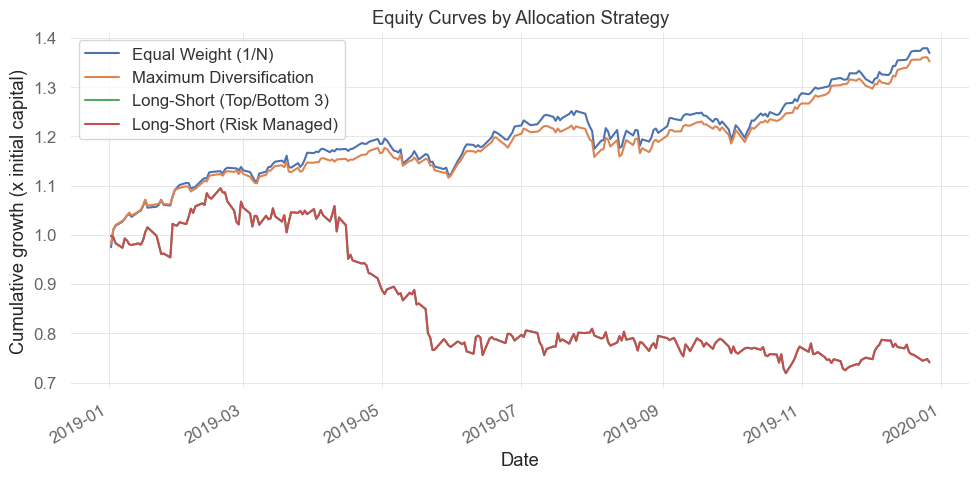

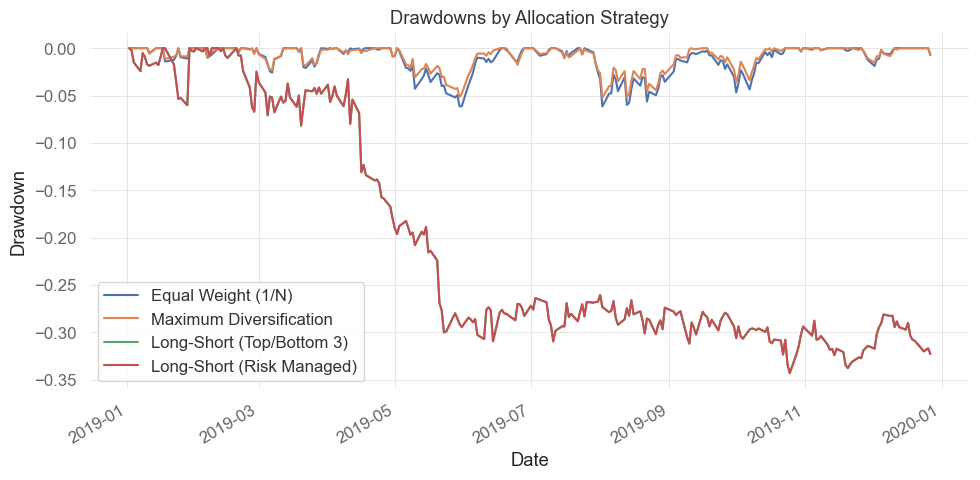

In [82]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
equity_curves.plot(ax=ax)
ax.set_title('Equity Curves by Allocation Strategy')
ax.set_ylabel('Cumulative growth (x initial capital)')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
drawdowns.plot(ax=ax)
ax.set_title('Drawdowns by Allocation Strategy')
ax.set_ylabel('Drawdown')
ax.set_xlabel('Date')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()


In [83]:
from src.helpers._extract import ensure_dir
import quantstats as qs

strategy_label = 'Long-Short (Risk Managed)'
equity_series = equity_curves[strategy_label]
equity = equity_series.rename('Classifier Long-Short Equity')

strategy_rets = equity.pct_change(fill_method=None).dropna()
strategy_rets.name = 'Classifier Long-Short'

df_factors = panel.reset_index()

if 'rf_lag1' in df_factors.columns:
    rf_by_date = (
        df_factors[['date', 'rf_lag1']]
        .dropna()
        .groupby('date', as_index=True)['rf_lag1']
        .mean()
        .astype(float)
        .sort_index()
    )
else:
    rf_by_date = pd.Series(dtype=float)

if 'mktrf_lag1' in df_factors.columns:
    mktrf_by_date = (
        df_factors[['date', 'mktrf_lag1']]
        .dropna()
        .groupby('date', as_index=True)['mktrf_lag1']
        .mean()
        .astype(float)
        .sort_index()
    )
else:
    mktrf_by_date = pd.Series(dtype=float)

if rf_by_date.empty:
    rf_series = pd.Series(0.0, index=strategy_rets.index, name='RiskFree')
else:
    rf_series = rf_by_date.reindex(strategy_rets.index).ffill().bfill()
    rf_series.name = 'RiskFree'

if mktrf_by_date.empty:
    bench_rets = pd.Series(0.0, index=strategy_rets.index, name='Market')
else:
    bench_raw = mktrf_by_date + rf_by_date.reindex(mktrf_by_date.index).fillna(0.0)
    bench_rets = bench_raw.reindex(strategy_rets.index).ffill().bfill()
    bench_rets.name = 'Market'

strategy_excess = (strategy_rets - rf_series).dropna()
bench_excess = (bench_rets - rf_series).reindex(strategy_excess.index).dropna()

common_idx = strategy_excess.index.intersection(bench_excess.index)
strategy_excess = strategy_excess.reindex(common_idx)
bench_excess = bench_excess.reindex(common_idx)

if strategy_excess.empty or bench_excess.empty:
    warnings.warn('Not enough data to generate QuantStats report for long-short strategy.')
else:
    ensure_dir('out')
    qs.reports.html(
        strategy_excess,
        benchmark=bench_excess.to_frame('Market'),
        rf=0.0,
        periods_per_year=252,
        output='out/classifier_long_short_tearsheet.html',
        title='Classifier Probability-Based Long-Short Strategy',
    )
    print('QuantStats report saved to out/classifier_long_short_tearsheet.html')


c:\Users\justi\OneDrive\Documentos\HEC Montreal\1st semester\Empirical Finance\Term Assignment\MATH60610A-portfolio-backtesting\.venv\Lib\site-packages\quantstats\stats.py:497: UserWarning: No non-zero returns found for win rate calculation, returning 0.0
  warn("No non-zero returns found for win rate calculation, returning 0.0")
c:\Users\justi\OneDrive\Documentos\HEC Montreal\1st semester\Empirical Finance\Term Assignment\MATH60610A-portfolio-backtesting\.venv\Lib\site-packages\quantstats\stats.py:497: UserWarning: No non-zero returns found for win rate calculation, returning 0.0
  warn("No non-zero returns found for win rate calculation, returning 0.0")
c:\Users\justi\OneDrive\Documentos\HEC Montreal\1st semester\Empirical Finance\Term Assignment\MATH60610A-portfolio-backtesting\.venv\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\justi\OneDrive\Documentos\HEC Montreal\1st se

QuantStats report saved to out/classifier_long_short_tearsheet.html


### Coefficient Inspection

In [84]:

coef_series = pd.Series(
    logit_pipeline.named_steps['logit'].coef_.ravel(),
    index=X_train.columns
)
coef_table = (
    pd.DataFrame({'coefficient': coef_series, 'abs_coef': coef_series.abs()})
    .sort_values('abs_coef', ascending=False)
)
coef_table


,coefficient,abs_coef
adjclose_lag0,-0.041316,0.041316
adjclose_lag1,-0.029384,0.029384
adjclose_lag3,-0.019901,0.019901
eom_14,-0.015019,0.015019
psar_acc,0.011850,0.011850
adjclose_lag2,-0.005323,0.005323


### Test-Set Metrics

In [85]:

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

proba_test = logit_pipeline.predict_proba(X_test)[:, 1]
preds_test = (proba_test >= 0.5).astype(int)

metrics = {
    'accuracy': accuracy_score(y_test, preds_test),
    'precision': precision_score(y_test, preds_test),
    'recall': recall_score(y_test, preds_test),
    'f1': f1_score(y_test, preds_test),
    'roc_auc': roc_auc_score(y_test, proba_test),
}
metrics


{'accuracy': 0.5071698113207547,
 'precision': 0.5686927560366362,
 'recall': 0.46430999320190347,
 'f1': 0.5112275449101796,
 'roc_auc': 0.5139431323945156}

In [86]:

conf_matrix = confusion_matrix(y_test, preds_test)
pd.DataFrame(conf_matrix, index=['Actual Sell (0)', 'Actual Buy (1)'], columns=['Pred Sell (0)', 'Pred Buy (1)'])


,Pred Sell (0),Pred Buy (1)
Actual Sell (0),6610,5180
Actual Buy (1),7880,6830


### Probability Distribution (Test Set)

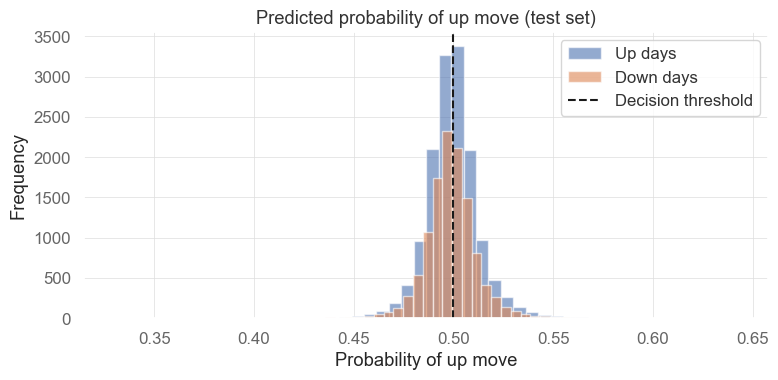

In [87]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(proba_test[y_test == 1], bins=50, alpha=0.6, label='Up days')
plt.hist(proba_test[y_test == 0], bins=50, alpha=0.6, label='Down days')
plt.axvline(0.5, color='k', linestyle='--', label='Decision threshold')
plt.title('Predicted probability of up move (test set)')
plt.xlabel('Probability of up move')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()


In [88]:
display(logit_fit_metrics)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, balanced_accuracy_score, roc_auc_score

test_metrics = pd.Series({
    'Accuracy': accuracy_score(y_test, test_pred),
    'Balanced accuracy': balanced_accuracy_score(y_test, test_pred),
    'Precision': precision_score(y_test, test_pred, zero_division=0),
    'Recall': recall_score(y_test, test_pred, zero_division=0),
    'F1-score': f1_score(y_test, test_pred, zero_division=0),
    'ROC AUC': roc_auc_score(y_test, test_prob),
})

display(test_metrics.to_frame(name='Value'))
print('Classification report (test set):')
print(classification_report(y_test, test_pred, zero_division=0))
print('Confusion matrix (test set):')
print(confusion_matrix(y_test, test_pred))


,Metric,Value
0,Train accuracy,0.512800
1,Test accuracy,0.507170
2,Test baseline (majority class),0.555094


,Value
Accuracy,0.507170
Balanced accuracy,0.512477
Precision,0.568693
Recall,0.464310
F1-score,0.511228
ROC AUC,0.513943


Classification report (test set):
              precision    recall  f1-score   support

           0       0.46      0.56      0.50     11790
           1       0.57      0.46      0.51     14710

    accuracy                           0.51     26500
   macro avg       0.51      0.51      0.51     26500
weighted avg       0.52      0.51      0.51     26500

Confusion matrix (test set):
[[6610 5180]
 [7880 6830]]
